# <a id='toc1_'></a>[Impact of Zero Location on System Model (Notch)](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Impact of Zero Location on System Model (Notch)](#toc1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [9]:
colors = bm.get_colors()

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

import control as ct
import control.matlab as cmat

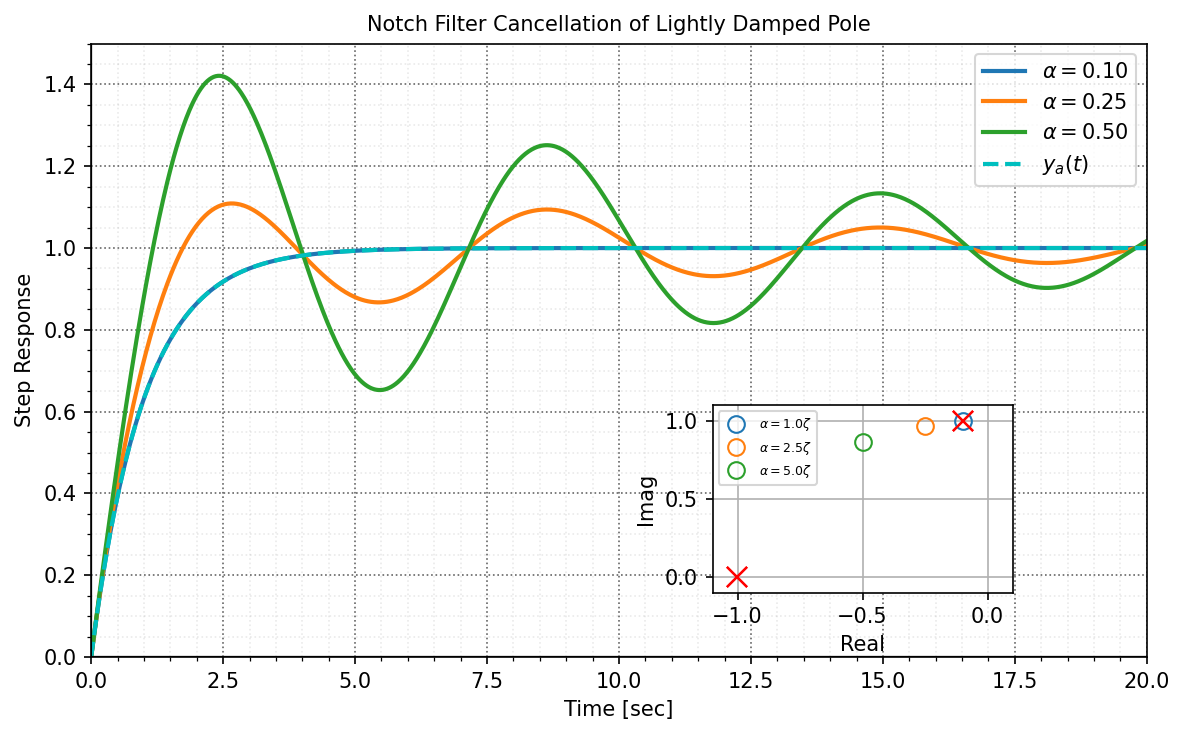

In [10]:
# Lecture 6-22
zeta = 0.1
wn = 1
tt = np.linspace(0,20,1000)
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,sharex = True)
ax.set_xlabel("Time [sec]")
ax.set_ylabel("Step Response")
bm.nicegrid(ax)

left, bottom, width, height = [0.6, 0.2, 0.25, 0.25]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.figure.set_facecolor('w')
bm.nicegrid(ax)
ax2.set_xlabel("Real")
ax2.set_ylabel("Imag")

for alp in np.array([0.1, 0.25, 0.5]):
    G = ct.tf((1, 2*alp*wn, wn**2), np.convolve((1, 2*zeta*wn, wn**2),(1,1)))
    [yy,tt] = cmat.step(G,tt)
    ax.plot(tt,yy,label=r'$\alpha={:3.2f}$'.format(alp))

    ax2.plot(np.real(G.poles()),np.imag(G.poles()), 'x', ms=10, color='red')
    ax2.plot(np.real(G.zeros()),np.imag(G.zeros()), 'o', markerfacecolor='none', ms=8, label=r'$\alpha={:2.1f}\zeta$'.format(alp/zeta))
    
Ga = ct.tf((1), (1,1))
[yya,tt] = cmat.step(Ga,tt)
ax.plot(tt,yya,'c--',label=r'$y_a(t)$')
ax.set_title(r"Notch Filter Cancellation of Lightly Damped Pole")
ax.legend()
ax2.legend(prop = { "size": 6 })
ax.set_ylim((0,1.5))
ax2.set_xlim((-1.1,0.1))
ax2.set_ylim((-0.1,1.1))
bm.nicegrid(ax)
plt.savefig("./figs/Zeros_Ex4_"+str(round(zeta,3))+".pdf", dpi=600)
plt.show()

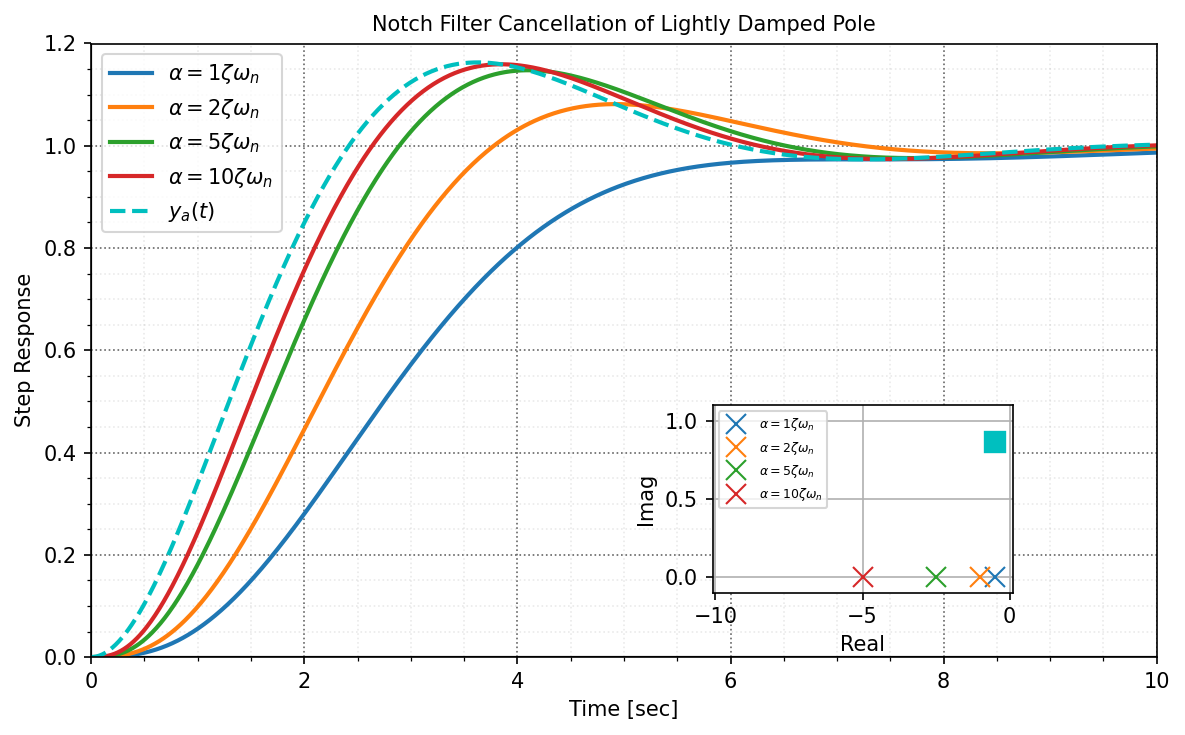

In [11]:
# Lecture 4-22 -- add pole
zeta = 0.5
wn = 1
tt = np.linspace(0,10,1000)
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,sharex = True)
ax.set_xlabel("Time [sec]")
ax.set_ylabel("Step Response")
bm.nicegrid(ax)

left, bottom, width, height = [0.6, 0.2, 0.25, 0.25]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.figure.set_facecolor('w')
bm.nicegrid(ax)
ax2.set_xlabel("Real")
ax2.set_ylabel("Imag")

Ga = ct.tf((wn**2), (1, 2*zeta*wn, wn**2))
for alp in np.array([1,2,5,10]):
    Gp = ct.tf(1, (1/(alp*zeta*wn),1))
    G = Ga*Gp
    [yy,tt] = cmat.step(G,tt)
    ax.plot(tt,yy,label=r'$\alpha={:3.0f}\zeta\omega_n$'.format(alp))

    ax2.plot(np.real(Ga.poles()),np.imag(Ga.poles()), 'cs', ms=10)
    ax2.plot(np.real(Gp.poles()),np.imag(Gp.poles()), 'x', ms=10, label=r'$\alpha={:2.0f}\zeta\omega_n$'.format(alp))
    
[yya,tt] = cmat.step(Ga,tt)
ax.plot(tt,yya,'c--',label=r'$y_a(t)$')
ax.set_title(r"Notch Filter Cancellation of Lightly Damped Pole")
ax.legend()
ax2.legend(prop = { "size": 6 })
ax.set_ylim((0,1.2))
ax2.set_xlim((-10.1,0.1))
ax2.set_ylim((-0.1,1.1))
plt.savefig("./figs/Zeros_Ex5_"+str(round(zeta,3))+".pdf", dpi=600)
plt.show()